In [1]:
# Standard Libraries
import math
import pickle
import random
import numpy as np

# Data Manipulation and Visualization
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

# Quantum Computing
import pennylane as qml

# Deep Learning
import torch
from torch.autograd import Variable
from torchvision import datasets, transforms

# Utility Functions
from functools import reduce

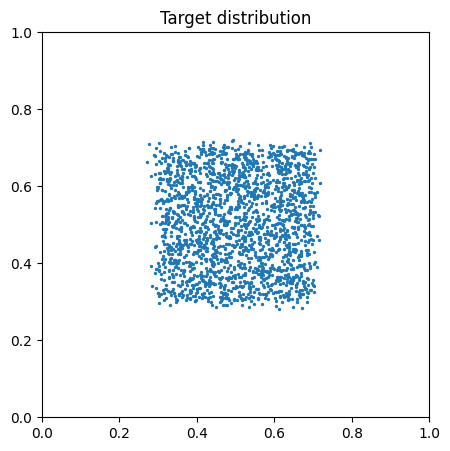

In [2]:
data_num = 2000
x = np.loadtxt(f'data/2D/box_{data_num}_1.txt') # 바로 점 데이터를 불러옴
plt.figure(figsize=(5,5))
plt.scatter(x[:,0], x[:,1], s=2.0)
plt.title('Target distribution')
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

In [3]:
# setting torch device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
noise_qubits = 3
code_qubits = 2
n_qubits = noise_qubits + code_qubits
output_qubits = 2
assert(output_qubits <= noise_qubits) # 출력 큐빗은 noise qubit이하여야 한다.

n_layers = 5
print("n_qubits = {} n_layers = {}".format(n_qubits, n_layers))

dev = qml.device("default.qubit", wires=n_qubits)
# dev = qml.device("ionq.simulator", wires=2)
# dev = qml.device("ionq.qpu", wires=2)

n_qubits = 5 n_layers = 5


## QGAN 모듈을 불러오자
TODO: QGAN 모듈 고쳐서 작동하게끔 해야함.

In [18]:
import importlib
import matplotlib.pyplot as plt
from modules import QGAN  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신

# 클래스 인스턴스 생성
idx = 5
generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi, np.pi, (n_layers, n_qubits, 3))), requires_grad=True)
generator = QGAN.QGAN(n_qubits, output_qubits, n_layers, generator_initial_params, dev)

Evaluation

100%|██████████| 100/100 [00:03<00:00, 33.21it/s]


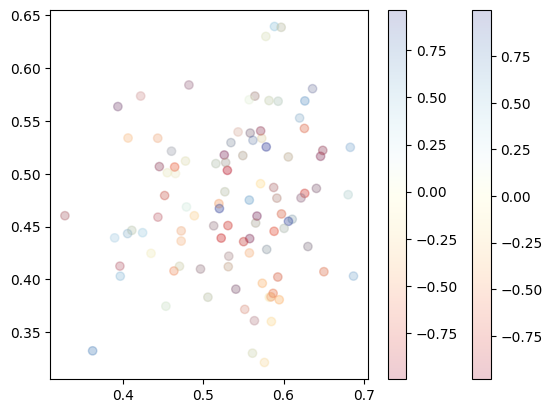

In [25]:
def bitwise_sums(arr):
    n = len(arr).bit_length() - 1
    return [sum(arr[i] for i in range(len(arr)) if (i >> bit) & 1) for bit in range(n)]

inputs = []
outputs = []
num = 100
points = np.zeros((num, 3 * code_qubits))

for i in tqdm(range(num)):
    with torch.no_grad():
        z = np.random.uniform(-1, 1, (1, n_qubits))
        code_input = z[:, -code_qubits:].reshape(code_qubits) # 입력 z중에서 code를 추출한다.
        output_probs =  generator.forward(z).numpy().flatten()
        generator_output = bitwise_sums(output_probs)

        for j in range(code_qubits):
            points[i][j*3] = generator_output[0]
            points[i][j*3+1] = generator_output[1]
            points[i][j*3+2] = code_input[j]
        outputs.append(generator_output)
        inputs.append(code_input)

inputs = np.array(inputs).reshape(-1, code_qubits)

for code_ind in range(code_qubits):
    outputs = np.array(outputs)
    plt.scatter(outputs[:, 0], outputs[:, 1], c=inputs[:, code_ind], cmap='RdYlBu', alpha=0.2)
    plt.colorbar()  # 색상 막대 추가
    # plt.title(f'code{code_ind}-distribution (rep = {final_rep})')
    # plt.savefig(f'result/{title}/code_{code_ind}_{final_rep}.png')
    # plt.show()